In [9]:
# Al inicio del notebook, agregar estas líneas:
%load_ext autoreload
%autoreload 2

import matplotlib.image as mpimg
import concurrent.futures
import numpy as np
import subprocess
import shutil
import sys
import os

from datetime import datetime
from pathlib import Path

from RRAM import simulation_config

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
def setup_project_structure():
    """Crea todas las carpetas necesarias antes de ejecutar las simulaciones."""

    folders = [
        "Init_data",
        "Datos_Experimentales/Ciclos_Experimentales",
        "Results",
        "Results/Figures",
        "logs",
        "Backup",  # (opcional)
    ]

    for folder in folders:
        Path(folder).mkdir(parents=True, exist_ok=True)
        print(f"✅ Creada carpeta: {folder}/")

    # Advertencia sobre archivos que el usuario debe proporcionar
    exp_files = [
        "Datos_Experimentales/Ciclos_Experimentales/Cycle_p_1000.txt",
        "Datos_Experimentales/Ciclos_Experimentales/Cycle_n_1000.txt",
    ]

    print("\n⚠️  Archivos que DEBES proporcionar manualmente:")
    for f in exp_files:
        if not os.path.exists(f):
            print(f"  ❌ {f}")
        else:
            print(f"  ✅ {f}")


if __name__ == "__main__":
    setup_project_structure()


✅ Creada carpeta: Init_data/
✅ Creada carpeta: Datos_Experimentales/Ciclos_Experimentales/
✅ Creada carpeta: Results/
✅ Creada carpeta: Results/Figures/
✅ Creada carpeta: logs/
✅ Creada carpeta: Backup/

⚠️  Archivos que DEBES proporcionar manualmente:
  ✅ Datos_Experimentales/Ciclos_Experimentales/Cycle_p_1000.txt
  ✅ Datos_Experimentales/Ciclos_Experimentales/Cycle_n_1000.txt


In [11]:
ruta_raiz = os.getcwd() + "/"
print("Ruta raiz del proyecto:", ruta_raiz)
sys.path.append(ruta_raiz)

# Ruta proporcionada
ruta_exp_data = ruta_raiz + "Datos_Experimentales/Ciclos_Experimentales"
ruta_init_data = ruta_raiz + "Initial_data/"

# Función para borrar y crear una carpeta de forma segura
def safe_reset_folder(folder_path):
    # Evita borrar carpetas peligrosas como la raíz del usuario
    if folder_path.strip().lower() in [
        "c:/users/usuario",
        "c:\\users\\usuario",
        "c:/users",
        "c:\\users",
    ]:
        print(f"ADVERTENCIA: No se permite borrar la carpeta protegida: {folder_path}")
        return
    try:
        if os.path.exists(folder_path):
            shutil.rmtree(folder_path)
        os.makedirs(folder_path)
    except PermissionError as e:
        print(
            f"Error de permisos al intentar borrar o crear la carpeta: {folder_path}\n{e}"
        )
    except Exception as e:
        print(f"Error inesperado con la carpeta: {folder_path}\n{e}")

# Borro los datos iniciales de la simulación anterior de forma segura
safe_reset_folder(ruta_init_data)

Ruta raiz del proyecto: /Users/antonio_lopez_torres/Documents/GitHub/RRAM_Simulation/


### Creación de la estructura de carpetas

In [12]:
# Defino la carpeta donde se guardan los datos iniciales de la simulación
carpeta_results = 'Results'

simulation_path = os.path.join(carpeta_results)

# Verifica si la carpeta existe
if os.path.exists(simulation_path):
    # Elimina la carpeta y su contenido
    shutil.rmtree(simulation_path)

    # crea la carpeta
    os.makedirs(simulation_path)
    os.makedirs(simulation_path + '/Figures')

#### Generación de parámetros iniciales

In [13]:
manager = simulation_config.ConfigManager()
carpeta_init = "Init_data"

# 1. Definimos las listas originales respetando tu "fuerza bruta" de Montecarlo
# Generamos listas repetidas 10 veces para E_a y E_r para replicar la aleatoriedad
factors_set = [1]
factors_reset = [1, 1.04]

E_a_base = 1.08
E_r_base = 1.3

# Valores de pendiente temperatura para el barrido son 5 valores partiendo de 26 hasta su 90% (aproximadamente 23.4) redondeados a 3 decimales
pendiente_temperatura_values = np.round(np.linspace(-26, -23.4, 5), 3).tolist()

print("Valores de pendiente de temperatura para el barrido:", pendiente_temperatura_values)

# 2. Diccionario de barrido (Grid Search)
# Todo lo que cruces aquí se multiplicará matemáticamente
parametros_barrido = {
    # Constantes
    "gamma": [10],
    "device_size_y": [12.5e-9],  # Añade más valores de tamaño de dispositivo para el barrido
    # Resistencias
    "ohm_resistence_set": [4],
    "ohm_resistence_reset": [4],
    "factor_generar_calor": [2.5e-5, 2.65e-5,2.85e-5],
    "pendiente_temperatura": [-24.7],  # Repite los valores de pendiente de temperatura para tener más simulaciones
    "grosor_filamento": [[0, 1], [1, 0]],  # Añade más valores de grosor de filamento para el barrido
    # Repito varias simulaciones con los mismos valores para tener varios casos "iguales"
    "generation_energy": [round(E_a_base * f, 3) for f in factors_set],
    "recombination_energy": [round(E_r_base * f, 3) for f in factors_reset],
}

# 3. Construimos y exportamos
manager.add_sweep(sweep_params=parametros_barrido)
manager.export_to_init_data(carpeta_init)

# 4. Lanzamos el script de creación de matrices (Init_simulation.py)
# Ya no hace falta pasarle argumentos porque lee el CSV automáticamente
import subprocess
print("\nLlamando a Init_simulation.py...")
resultado = subprocess.run(["python", ruta_raiz + "Init_simulation.py"], capture_output=True, text=True)
print(resultado.stdout)
if resultado.stderr:
    print("ERRORES:", resultado.stderr)

Valores de pendiente de temperatura para el barrido: [-26.0, -25.35, -24.7, -24.05, -23.4]
-> Generadas 12 combinaciones.
✅ Exportados parámetros y constantes (12 casos) a Init_data/

Llamando a Init_simulation.py...
Construyendo estados iniciales para 12 simulaciones...

Simulación 0: Tamaño del dispositivo = (50, 40), Número de trampas = 70
 Los rangos de los filamentos son: [(0, 19), (20, 49)] y las regiones de peso son: [((7, 12, 0, 40), 70), ((32, 37, 0, 40), 70)]


Simulación 1: Tamaño del dispositivo = (50, 40), Número de trampas = 70
 Los rangos de los filamentos son: [(0, 19), (20, 49)] y las regiones de peso son: [((7, 12, 0, 40), 70), ((32, 37, 0, 40), 70)]


Simulación 2: Tamaño del dispositivo = (50, 40), Número de trampas = 70
 Los rangos de los filamentos son: [(0, 19), (20, 49)] y las regiones de peso son: [((7, 12, 0, 40), 70), ((32, 37, 0, 40), 70)]


Simulación 3: Tamaño del dispositivo = (50, 40), Número de trampas = 70
 Los rangos de los filamentos son: [(0, 19), (

In [14]:
# Paralelización con hilos (funciona en Jupyter)
num_simulaciones = len(manager.simulations)

print(f"Se van a ejecutar {num_simulaciones} simulaciones\n")

ruta_raiz = Path.cwd()
carpeta_results = ruta_raiz / "Results"

# Elimino la capreta de resultados anterior
if (carpeta_results).exists():
    shutil.rmtree(carpeta_results)
    carpeta_results.mkdir(parents=True, exist_ok=True)

global_figures_path = Path.cwd() / "Results" / "Figures"
global_figures_path.mkdir(parents=True, exist_ok=True)

Se van a ejecutar 12 simulaciones



In [15]:
import time  # Importamos el módulo para medir el tiempo

path = os.getcwd() + '/'

# Carpeta donde se guardarán los logs
log_dir = "logs"
os.makedirs(log_dir, exist_ok=True)  # Crea la carpeta si no existe

# Limpio la carpeta de logs antes de empezar
for file in os.listdir(log_dir):
    file_path = os.path.join(log_dir, file)
    try:
        if os.path.isfile(file_path):
            os.unlink(file_path)
    except Exception as e:
        print(f"No se pudo eliminar {file_path}. Error: {e}")

# Función que ejecuta una simulación y guarda su propio log
guardar_datos = False  # Cambiado a False para evitar guardar datos de configuracion en cada simulación
num_filametos = 1

def ejecutar_simulacion(num_simulacion):
    log_file_path = os.path.join(log_dir, f"log_simulacion_{num_simulacion + 1}.log")

    with open(log_file_path, 'w') as log_file:
        print(f"Iniciando simulación {num_simulacion+1}")
        subprocess.run(
            [
                "python",
                path + "RRAM_mod_simulation.py",
                str(num_simulacion),
                str(guardar_datos),
                str(num_filametos),
            ],
            stdout=log_file,
            stderr=log_file,
        )

# Inicia el contador de tiempo
start_time = time.time()

print(f"Se van a ejecutar {num_simulaciones} simulaciones:\n")

num_procesadores = int(0.5*(os.cpu_count())) or 10  # type: ignore

with concurrent.futures.ThreadPoolExecutor(
    max_workers=num_procesadores
) as executor:  # Usa hilos en vez de procesos
    executor.map(ejecutar_simulacion, range(num_simulaciones))

# Finaliza el contador de tiempo
end_time = time.time()

# Calcula e imprime el tiempo total de ejecución
elapsed_time = end_time - start_time

elapsed_time=elapsed_time/3600  # Convertir a horas

print(f"Todas las simulaciones han terminado")
print(f"Tiempo total de ejecución: {elapsed_time:.2f} horas")

Se van a ejecutar 12 simulaciones:

Iniciando simulación 1
Iniciando simulación 2
Iniciando simulación 3
Iniciando simulación 4
Iniciando simulación 5
Iniciando simulación 6
Iniciando simulación 7
Iniciando simulación 8
Iniciando simulación 9
Iniciando simulación 10
Iniciando simulación 11
Iniciando simulación 12
Todas las simulaciones han terminado
Tiempo total de ejecución: 0.16 horas


### Representación de resultados

In [16]:
import numpy as np
from pathlib import Path
from RRAM import Representate

# 1. Definir la ruta del archivo de datos .npz
# Asegúrate de ajustar esta ruta si tu archivo se encuentra en otra carpeta
num_simulacion = 2
num_paso = 4000
etapa = "pp_set"

ruta_npz = Path(
    f"/Users/antonio_lopez_torres/Documents/GitHub/RRAM_Simulation/Results/simulation_{num_simulacion}/{etapa.split('_')[1]}/Estado_pp_set_sim_{num_simulacion}_paso_{num_paso}.npz"
)

# 2. Cargar el archivo comprimido usando NumPy
datos_estado = np.load(ruta_npz)

# 3. Extraer la matriz de estado
# El archivo .npz contiene varias matrices; accedemos a 'actual_state' mediante su clave
matriz_estado = datos_estado["actual_state"]

# Opcional: También puedes acceder a otras variables como la temperatura si lo necesitas después
# matriz_temperatura = datos_estado['temperatura']

# 4. Configurar los parámetros de la representación
voltaje_simulacion = num_paso * 0.00011  # Ajusta este valor al voltaje real aplicado en este paso
ruta_figura = Path.cwd() / f"Estado_{etapa}_sim_{num_simulacion}_paso_{num_paso}.png"

# 5. Llamar a la función RepresentateState para generar el gráfico
Representate.RepresentateState(matriz=matriz_estado, voltaje=round(voltaje_simulacion, 5), filename=str(ruta_figura))

print(f"La imagen del estado se ha generado correctamente en: {ruta_figura}")

print(matriz_estado)

Dimensiones del dispositivo: 10.00 nm x 12.50 nm
La imagen del estado se ha generado correctamente en: /Users/antonio_lopez_torres/Documents/GitHub/RRAM_Simulation/Estado_pp_set_sim_2_paso_4000.png
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


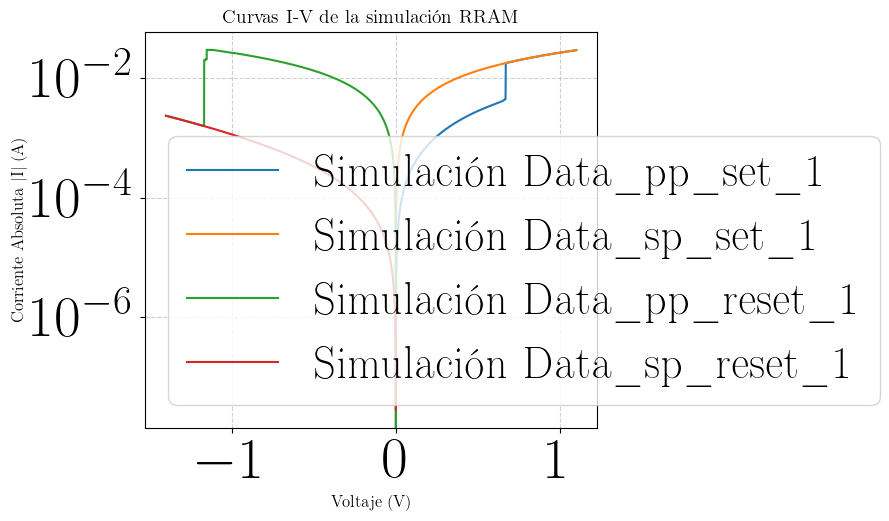

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Nombres de tus 4 archivos
archivos = [
    "Results/simulation_1/Data_pp_set_1.npz",
    "Results/simulation_1/Data_sp_set_1.npz",
    "Results/simulation_1/Data_pp_reset_1.npz",
    "Results/simulation_1/Data_sp_reset_1.npz",
]

plt.figure(figsize=(8, 6))

for archivo in archivos:
    ruta = Path(archivo)

    if ruta.exists():
        # Cargar el archivo .npz
        datos = np.load(ruta)

        # Extraer la matriz de datos. Asumimos que se guardó bajo la clave 'datos_sim'
        # Si el nombre de la clave es distinto, puedes comprobarlo con datos.files
        matriz = datos["datos_sim"]

        # Columna 1: Voltaje (V)
        voltaje = matriz[:, 1]
        # Columna 2: Corriente (I)
        corriente = matriz[:, 2]

        # Graficar (usamos el valor absoluto de la corriente para poder poner escala logarítmica)
        plt.plot(voltaje, np.abs(corriente), label=f"Simulación {ruta.stem}")
    else:
        print(f"El archivo {archivo} no se encontró en la ruta especificada.")

# Configuración de la gráfica
plt.title("Curvas I-V de la simulación RRAM", fontsize=14)
plt.xlabel("Voltaje (V)", fontsize=12)
plt.ylabel("Corriente Absoluta |I| (A)", fontsize=12)

# Las curvas I-V de RRAM suelen verse mejor en escala semilogarítmica (eje Y)
plt.yscale("log")

plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend()
plt.tight_layout()

# Guardar la imagen y mostrarla
plt.savefig("Grafica_IV_Conjunta.png", dpi=300)
plt.show()
